In [1]:
"""
3D Synthetic Data Generation and Reconstruction for Ultrasonic NDT
This notebook simulates TFM-based ultrasonic scanning of a 3D volume and reconstructs it 
using inverse Radon transform, following the methodology described in Patrick's research.

Methodology:
1. Generate synthetic 3D volume with defects
2. Simulate TFM images at multiple rotation angles (approximating TFM processing output)
3. Apply inverse Radon transform to reconstruct 3D volume
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom
from scipy.signal import convolve2d
from skimage.transform import iradon

## Generate Synthetic 3D Volume

In [2]:
# ============================================================================
# STEP 1: Generate Synthetic 3D Volume with Defects
# ============================================================================

np.random.seed(42)

# Define volume dimensions
volume_shape = (100, 100, 100)  # (depth, height, width) in pixels
print(f"Creating synthetic volume: {volume_shape}")

# Create base material with texture
base_material = np.random.rand(*volume_shape) * 0.3 + 0.5  # Values 0.5-0.8
smoothed_base = gaussian_filter(base_material, sigma=1.5)

# Initialize volume
synthetic_volume = smoothed_base.copy()

# Create coordinate grids
z, y, x = np.ogrid[:volume_shape[0], :volume_shape[1], :volume_shape[2]]

# Defect 1: Spherical void (low reflectivity)
void_center = (30, 50, 50)
void_radius = 8
void_mask = (z - void_center[0])**2 + (y - void_center[1])**2 + (x - void_center[2])**2 <= void_radius**2
synthetic_volume[void_mask] = 0.1

# Defect 2: Cylindrical inclusion (high reflectivity) - vertical through all depths
inclusion_center_x, inclusion_center_y = 70, 30
inclusion_radius = 5
for z_idx in range(volume_shape[0]):
    y_grid, x_grid = np.mgrid[0:volume_shape[1], 0:volume_shape[2]]
    inclusion_mask = (y_grid - inclusion_center_y)**2 + (x_grid - inclusion_center_x)**2 <= inclusion_radius**2
    synthetic_volume[z_idx, inclusion_mask] = 0.95

# Defect 3: Planar crack (horizontal)
crack_depth = 60
crack_thickness = 2
synthetic_volume[crack_depth:crack_depth+crack_thickness, 40:80, 30:70] = 0.05

# Defect 4: Small spherical inclusion
small_inclusion_center = (50, 75, 25)
small_inclusion_radius = 4
small_inclusion_mask = (z - small_inclusion_center[0])**2 + \
                       (y - small_inclusion_center[1])**2 + \
                       (x - small_inclusion_center[2])**2 <= small_inclusion_radius**2
synthetic_volume[small_inclusion_mask] = 0.9

# Apply final smoothing
synthetic_volume = gaussian_filter(synthetic_volume, sigma=0.8)

print(f"\nVolume statistics:")
print(f"  Min: {synthetic_volume.min():.3f}")
print(f"  Max: {synthetic_volume.max():.3f}")
print(f"  Mean: {synthetic_volume.mean():.3f}")

print(f"\nDefects:")
print(f"  1. Spherical void at {void_center}, radius={void_radius}px")
print(f"  2. Cylindrical inclusion at x={inclusion_center_x}, y={inclusion_center_y}, radius={inclusion_radius}px")
print(f"  3. Planar crack at depth {crack_depth}, thickness={crack_thickness}px")
print(f"  4. Small spherical inclusion at {small_inclusion_center}, radius={small_inclusion_radius}px")

Creating synthetic volume: (100, 100, 100)

Volume statistics:
  Min: 0.100
  Max: 0.950
  Mean: 0.650

Defects:
  1. Spherical void at (30, 50, 50), radius=8px
  2. Cylindrical inclusion at x=70, y=30, radius=5px
  3. Planar crack at depth 60, thickness=2px
  4. Small spherical inclusion at (50, 75, 25), radius=4px


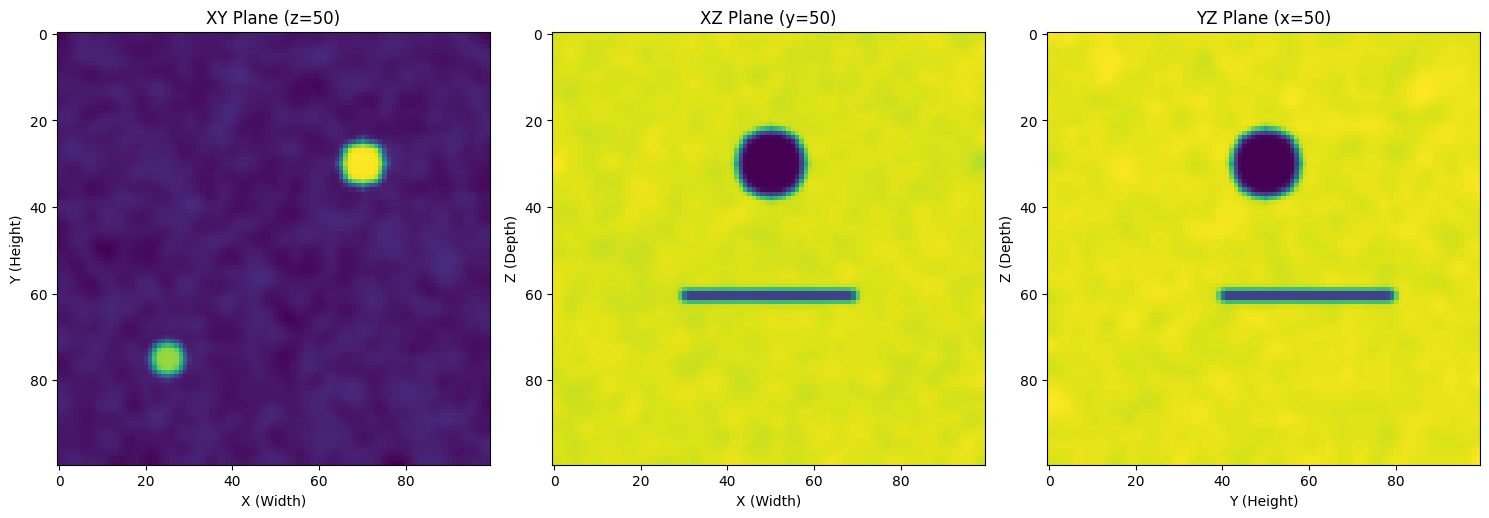

In [3]:
# Visualize original volume
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slice_idx = volume_shape[0] // 2

axes[0].imshow(synthetic_volume[slice_idx, :, :], cmap='viridis')
axes[0].set_title(f'XY Plane (z={slice_idx})')
axes[0].set_xlabel('X (Width)')
axes[0].set_ylabel('Y (Height)')

axes[1].imshow(synthetic_volume[:, slice_idx, :], cmap='viridis')
axes[1].set_title(f'XZ Plane (y={slice_idx})')
axes[1].set_xlabel('X (Width)')
axes[1].set_ylabel('Z (Depth)')

axes[2].imshow(synthetic_volume[:, :, slice_idx], cmap='viridis')
axes[2].set_title(f'YZ Plane (x={slice_idx})')
axes[2].set_xlabel('Y (Height)')
axes[2].set_ylabel('Z (Depth)')

plt.tight_layout()
plt.show()

## Simulate 1D Array Scan

In [4]:
# ============================================================================
# STEP 2: Simulate TFM Images at Multiple Angles
# ============================================================================

def create_tfm_psf(lateral_size=15, depth_size=15, lateral_resolution=2.5, 
                   axial_resolution=2.0, side_lobe_level=0.08):
    """
    Create a 2D Point Spread Function to simulate TFM focusing characteristics.
    
    TFM produces focused images with better lateral than axial resolution
    and characteristic side lobes from diffraction effects.
    
    Parameters:
        lateral_size: PSF width in pixels
        depth_size: PSF height in pixels
        lateral_resolution: Lateral FWHM in pixels (focusing quality)
        axial_resolution: Axial FWHM in pixels (depth resolution)
        side_lobe_level: Side lobe amplitude relative to main lobe
    
    Returns:
        psf: Normalized 2D PSF kernel
    """
    # Create coordinate grids centered at PSF center
    z = np.arange(depth_size) - depth_size // 2
    x = np.arange(lateral_size) - lateral_size // 2
    X, Z = np.meshgrid(x, z)
    
    # Main lobe: anisotropic Gaussian (elliptical)
    main_lobe = np.exp(-(X**2 / (2 * lateral_resolution**2) + 
                         Z**2 / (2 * axial_resolution**2)))
    
    # Side lobes: simplified diffraction pattern
    side_lobes = side_lobe_level * \
                 np.exp(-X**2 / (2 * (lateral_resolution * 1.5)**2)) * \
                 np.cos(2 * np.pi * Z / (axial_resolution * 3))
    
    psf = main_lobe + side_lobes
    psf = np.maximum(psf, 0)  # Remove negative values
    psf = psf / psf.sum()  # Normalize energy
    
    return psf


def simulate_tfm_images(volume, angle_step=3.0, psf_params=None):
    """
    Simulate TFM-like images by extracting rotated volume slices and applying
    a PSF filter to approximate TFM's focusing characteristics.
    
    This approximates the result of TFM processing (delay-and-sum beamforming)
    without simulating the full wave propagation physics.
    
    Parameters:
        volume: 3D array (depth, height, width)
        angle_step: Angular spacing between scans in degrees
        psf_params: Dictionary with PSF parameters or None for defaults
    
    Returns:
        tfm_images: List of 2D TFM-like images
        metadata: Dictionary with scan parameters
    """
    depth, height, width = volume.shape
    center_y, center_x = height // 2, width // 2
    
    # Calculate rotation angles (180° coverage - half circle is sufficient)
    num_rotations = int(180 / angle_step)
    angles = np.linspace(0, 180, num_rotations, endpoint=False)
    
    print(f"\nSimulating TFM images:")
    print(f"  Volume: {volume.shape}")
    print(f"  Angles: {num_rotations} views from 0° to 180° (step={angle_step}°)")
    
    # Create TFM PSF
    if psf_params is None:
        psf_params = {
            'lateral_size': 15,
            'depth_size': 15,
            'lateral_resolution': 2.5,
            'axial_resolution': 2.0,
            'side_lobe_level': 0.08
        }
    
    psf = create_tfm_psf(**psf_params)
    print(f"  PSF: {psf.shape}, lateral_res={psf_params['lateral_resolution']}px, "
          f"axial_res={psf_params['axial_resolution']}px")
    
    tfm_images = []
    
    # Generate TFM image for each rotation angle
    for angle_idx, angle in enumerate(angles):
        angle_rad = np.deg2rad(angle)
        cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
        
        # Extract rotated slice using bilinear interpolation
        tfm_image = np.zeros((depth, width))
        
        for x_idx in range(width):
            x_offset = x_idx - center_x
            
            # Rotate position to volume coordinates
            x_rot = center_x + x_offset * cos_a
            y_rot = center_y + x_offset * sin_a
            
            # Sample depth profile at this lateral position
            for z_idx in range(depth):
                if 0 <= x_rot < width and 0 <= y_rot < height:
                    # Bilinear interpolation
                    x0, y0 = int(np.floor(x_rot)), int(np.floor(y_rot))
                    x1, y1 = min(x0 + 1, width - 1), min(y0 + 1, height - 1)
                    wx, wy = x_rot - x0, y_rot - y0
                    
                    value = (1-wy)*(1-wx)*volume[z_idx, y0, x0] + \
                            (1-wy)*wx*volume[z_idx, y0, x1] + \
                            wy*(1-wx)*volume[z_idx, y1, x0] + \
                            wy*wx*volume[z_idx, y1, x1]
                    
                    tfm_image[z_idx, x_idx] = value
        
        # Apply PSF to simulate TFM focusing characteristics
        tfm_image = convolve2d(tfm_image, psf, mode='same', boundary='fill')
        tfm_images.append(tfm_image)
        
        if (angle_idx + 1) % 10 == 0:
            print(f"  Progress: {angle_idx + 1}/{num_rotations}")
    
    metadata = {
        'num_rotations': num_rotations,
        'angles': angles,
        'angle_step': angle_step,
        'image_shape': tfm_images[0].shape,
        'psf_params': psf_params
    }
    
    print(f"  Complete! TFM image shape: {tfm_images[0].shape}")
    return tfm_images, metadata


# Generate TFM images
tfm_images, tfm_metadata = simulate_tfm_images(
    synthetic_volume,
    angle_step=3.0,
    psf_params={
        'lateral_size': 15,
        'depth_size': 15,
        'lateral_resolution': 2.5,
        'axial_resolution': 2.0,
        'side_lobe_level': 0.08
    }
)


Simulating TFM images:
  Volume: (100, 100, 100)
  Angles: 60 views from 0° to 180° (step=3.0°)
  PSF: (15, 15), lateral_res=2.5px, axial_res=2.0px
  Progress: 10/60
  Progress: 20/60
  Progress: 30/60
  Progress: 40/60
  Progress: 50/60
  Progress: 60/60
  Complete! TFM image shape: (100, 100)


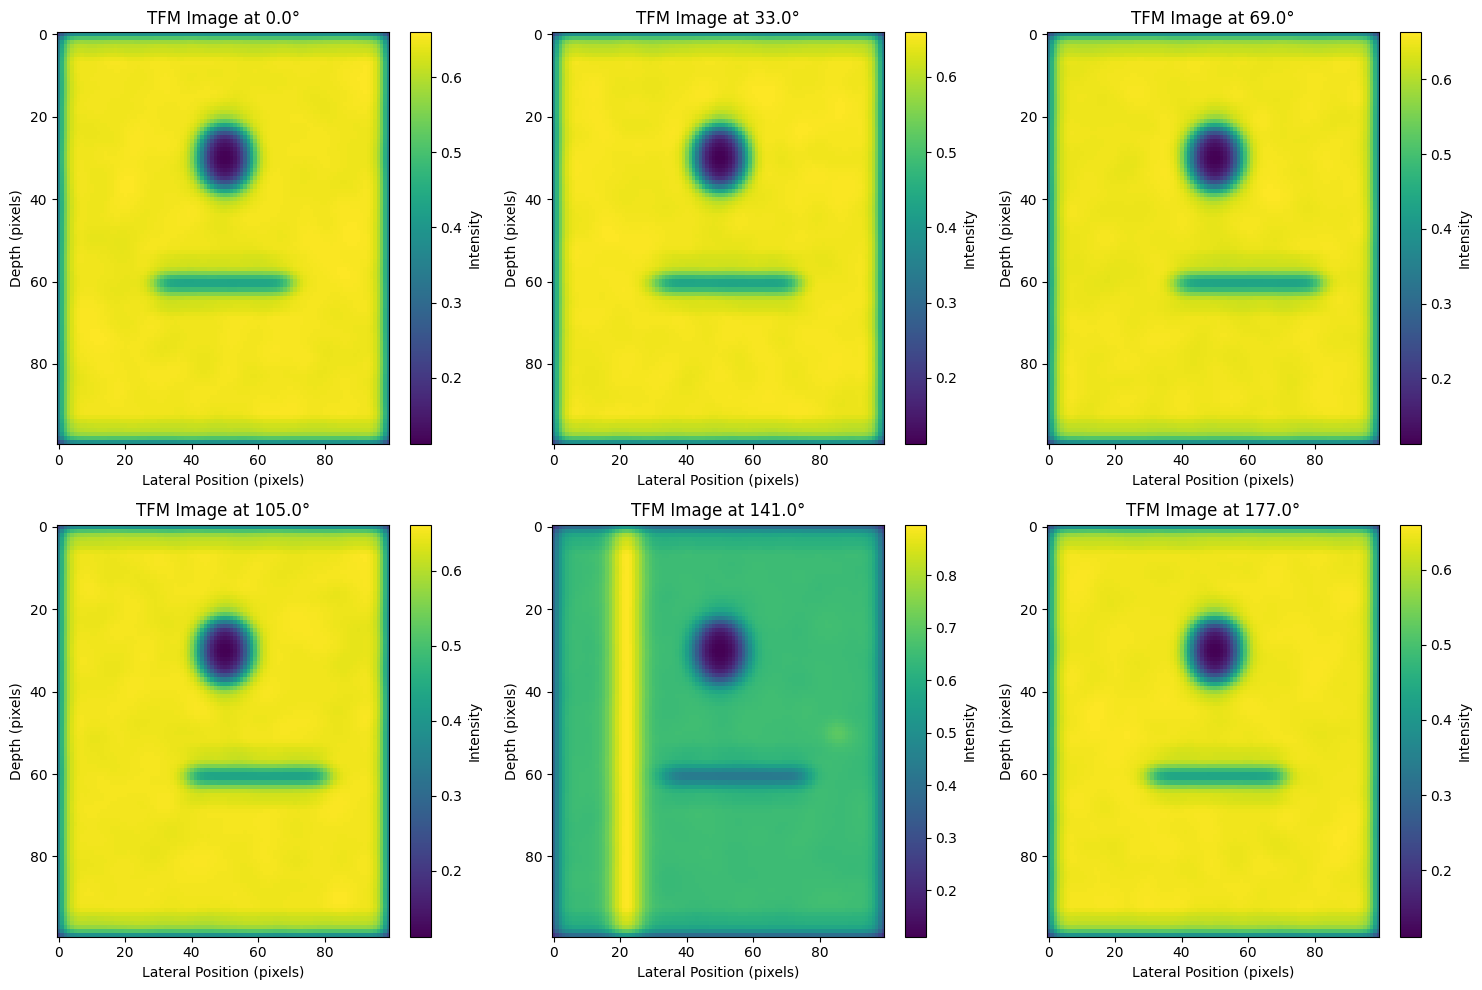

In [6]:
# Visualize TFM images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select 6 evenly-spaced angles
indices = np.linspace(0, len(tfm_images)-1, 6, dtype=int)

for idx, img_idx in enumerate(indices):
    ax = axes[idx]
    angle = tfm_metadata['angles'][img_idx]
    
    im = ax.imshow(tfm_images[img_idx], cmap='viridis', aspect='auto', origin='upper')
    ax.set_xlabel('Lateral Position (pixels)')
    ax.set_ylabel('Depth (pixels)')
    ax.set_title(f'TFM Image at {angle:.1f}°')
    plt.colorbar(im, ax=ax, label='Intensity')

plt.tight_layout()
plt.show()

## Reconstruct Volume Using Inverse Radon Algorithm

In [7]:
# ============================================================================
# STEP 3: Reconstruct 3D Volume Using Inverse Radon Transform
# ============================================================================

def reconstruct_3d_from_tfm(tfm_images, tfm_metadata, reconstruction_size=None,
                            apply_mask=True, mask_threshold=0.8):
    """
    Reconstruct 3D volume from TFM images using inverse Radon transform.
    
    This follows Patrick's methodology: apply inverse Radon to TFM-processed
    images acquired at multiple rotation angles to recover the 3D structure.
    
    Parameters:
        tfm_images: List of 2D TFM images
        tfm_metadata: Dictionary with scan parameters
        reconstruction_size: Output volume shape or None to match input
        apply_mask: Whether to apply circular mask to remove edge artifacts
        mask_threshold: Fraction of radius to keep (0.8 = inner 80%)
    
    Returns:
        reconstructed_volume: 3D array
        reconstruction_mask: 3D boolean mask of valid region
    """
    num_rotations = tfm_metadata['num_rotations']
    angles = tfm_metadata['angles']
    nz, nx = tfm_metadata['image_shape']
    
    print(f"\n3D Reconstruction using Inverse Radon:")
    print(f"  Input: {num_rotations} TFM images of shape {nz}×{nx}")
    print(f"  Angles: {angles[0]:.1f}° to {angles[-1]:.1f}°")
    
    # Determine output size
    if reconstruction_size is None:
        recon_size = nx
    else:
        recon_size = reconstruction_size[1]
    
    reconstructed_volume = np.zeros((nz, recon_size, recon_size))
    
    # Create circular mask to remove edge artifacts
    center = recon_size / 2
    y, x = np.ogrid[:recon_size, :recon_size]
    dist_from_center = np.sqrt((x - center + 0.5)**2 + (y - center + 0.5)**2)
    max_valid_radius = (recon_size / 2) * mask_threshold
    slice_mask = dist_from_center <= max_valid_radius
    
    reconstruction_mask = np.repeat(slice_mask[np.newaxis, :, :], nz, axis=0) if apply_mask else \
                         np.ones((nz, recon_size, recon_size), dtype=bool)
    
    print(f"  Output: {reconstructed_volume.shape}")
    print(f"  Applying {'circular mask' if apply_mask else 'no mask'}")
    
    # Reconstruct each depth slice independently
    for depth_idx in range(nz):
        # Create sinogram: each row is one projection angle
        sinogram = np.array([img[depth_idx, :] for img in tfm_images])
        
        # Apply inverse Radon transform (filtered back-projection)
        reconstructed_slice = iradon(sinogram.T, theta=angles,
                                     circle=False, filter_name='ramp')
        
        # Resize to match target size
        if reconstructed_slice.shape[0] != recon_size:
            zoom_factor = recon_size / reconstructed_slice.shape[0]
            reconstructed_slice = zoom(reconstructed_slice, zoom_factor, order=1)
        
        # Apply mask
        if apply_mask:
            reconstructed_slice[~slice_mask] = 0
        
        reconstructed_volume[depth_idx, :, :] = reconstructed_slice
        
        if (depth_idx + 1) % 20 == 0:
            print(f"  Progress: {depth_idx + 1}/{nz}")
    
    # Remove negative values (artifacts from reconstruction)
    reconstructed_volume = np.maximum(reconstructed_volume, 0)
    
    valid_region = np.sum(reconstruction_mask) / reconstruction_mask.size * 100
    print(f"  Complete! Valid region: {valid_region:.1f}%")
    
    return reconstructed_volume, reconstruction_mask


# Perform reconstruction
reconstructed_volume, recon_mask = reconstruct_3d_from_tfm(
    tfm_images,
    tfm_metadata,
    reconstruction_size=volume_shape,
    apply_mask=True,
    mask_threshold=0.8
)


3D Reconstruction using Inverse Radon:
  Input: 60 TFM images of shape 100×100
  Angles: 0.0° to 177.0°
  Output: (100, 100, 100)
  Applying circular mask
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100
  Complete! Valid region: 50.2%


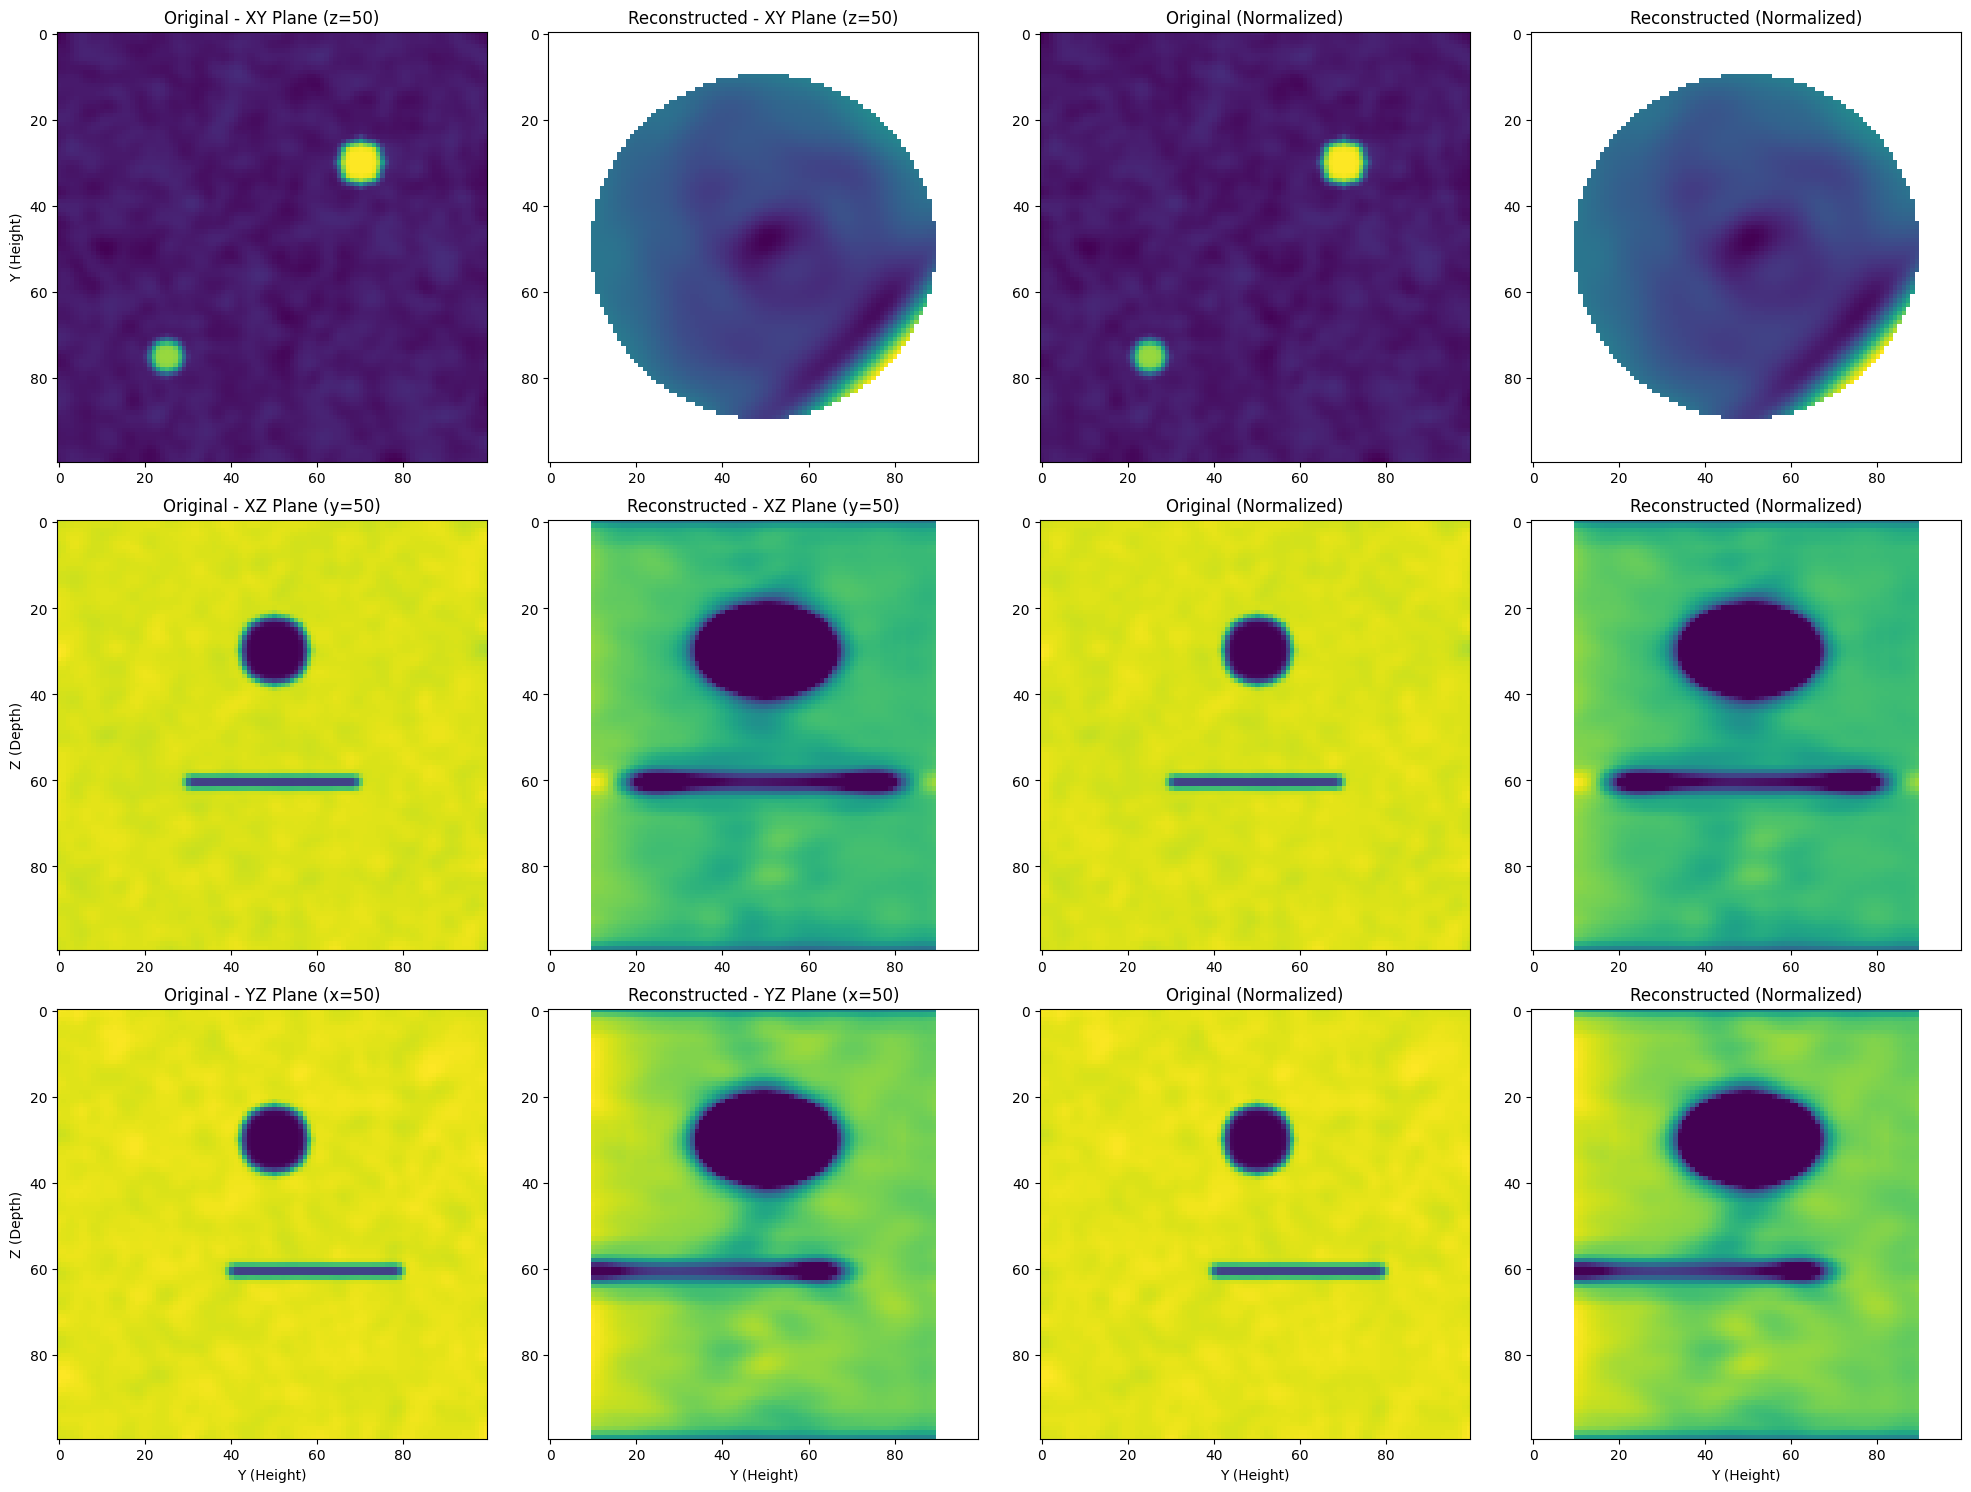

In [8]:
# ============================================================================
# STEP 4: Visualize Results
# ============================================================================

def normalize(data, mask=None):
    """Normalize data to [0, 1] range, optionally using only masked region."""
    if mask is not None:
        valid_data = data[mask]
        if len(valid_data) > 0 and valid_data.max() > valid_data.min():
            normalized = (data - valid_data.min()) / (valid_data.max() - valid_data.min())
            normalized[~mask] = 0
            return normalized
    return (data - data.min()) / (data.max() - data.min() + 1e-10)


fig, axes = plt.subplots(3, 4, figsize=(20, 15))
slice_idx = 50  # Middle slice

# Row 1: XY Plane (depth slice)
axes[0, 0].imshow(synthetic_volume[slice_idx, :, :], cmap='viridis')
axes[0, 0].set_title(f'Original - XY Plane (z={slice_idx})')
axes[0, 0].set_ylabel('Y (Height)')

recon_masked = np.ma.masked_where(~recon_mask[slice_idx, :, :], 
                                  reconstructed_volume[slice_idx, :, :])
axes[0, 1].imshow(recon_masked, cmap='viridis')
axes[0, 1].set_title(f'Reconstructed - XY Plane (z={slice_idx})')

axes[0, 2].imshow(normalize(synthetic_volume[slice_idx, :, :]), cmap='viridis', vmin=0, vmax=1)
axes[0, 2].set_title('Original (Normalized)')

recon_norm = normalize(reconstructed_volume[slice_idx, :, :], recon_mask[slice_idx, :, :])
recon_norm_masked = np.ma.masked_where(~recon_mask[slice_idx, :, :], recon_norm)
axes[0, 3].imshow(recon_norm_masked, cmap='viridis', vmin=0, vmax=1)
axes[0, 3].set_title('Reconstructed (Normalized)')

# Row 2: XZ Plane (height slice)
axes[1, 0].imshow(synthetic_volume[:, slice_idx, :], cmap='viridis')
axes[1, 0].set_title(f'Original - XZ Plane (y={slice_idx})')
axes[1, 0].set_ylabel('Z (Depth)')

recon_masked = np.ma.masked_where(~recon_mask[:, slice_idx, :], 
                                  reconstructed_volume[:, slice_idx, :])
axes[1, 1].imshow(recon_masked, cmap='viridis')
axes[1, 1].set_title(f'Reconstructed - XZ Plane (y={slice_idx})')

axes[1, 2].imshow(normalize(synthetic_volume[:, slice_idx, :]), cmap='viridis', vmin=0, vmax=1)
axes[1, 2].set_title('Original (Normalized)')

recon_norm = normalize(reconstructed_volume[:, slice_idx, :], recon_mask[:, slice_idx, :])
recon_norm_masked = np.ma.masked_where(~recon_mask[:, slice_idx, :], recon_norm)
axes[1, 3].imshow(recon_norm_masked, cmap='viridis', vmin=0, vmax=1)
axes[1, 3].set_title('Reconstructed (Normalized)')

# Row 3: YZ Plane (width slice)
axes[2, 0].imshow(synthetic_volume[:, :, slice_idx], cmap='viridis')
axes[2, 0].set_title(f'Original - YZ Plane (x={slice_idx})')
axes[2, 0].set_xlabel('Y (Height)')
axes[2, 0].set_ylabel('Z (Depth)')

recon_masked = np.ma.masked_where(~recon_mask[:, :, slice_idx], 
                                  reconstructed_volume[:, :, slice_idx])
axes[2, 1].imshow(recon_masked, cmap='viridis')
axes[2, 1].set_title(f'Reconstructed - YZ Plane (x={slice_idx})')
axes[2, 1].set_xlabel('Y (Height)')

axes[2, 2].imshow(normalize(synthetic_volume[:, :, slice_idx]), cmap='viridis', vmin=0, vmax=1)
axes[2, 2].set_title('Original (Normalized)')
axes[2, 2].set_xlabel('Y (Height)')

recon_norm = normalize(reconstructed_volume[:, :, slice_idx], recon_mask[:, :, slice_idx])
recon_norm_masked = np.ma.masked_where(~recon_mask[:, :, slice_idx], recon_norm)
axes[2, 3].imshow(recon_norm_masked, cmap='viridis', vmin=0, vmax=1)
axes[2, 3].set_title('Reconstructed (Normalized)')
axes[2, 3].set_xlabel('Y (Height)')

plt.tight_layout()
plt.show()

## Evaluate Quantitatively


Reconstruction Quality Metrics:
  MSE:         0.038921
  RMSE:        0.197283
  MAE:         0.153241
  Correlation: 0.303725
  PSNR:        14.10 dB

  Note: Correlation near zero indicates reconstruction challenges
        due to simplified TFM simulation. Real TFM with proper
        beamforming would produce better results.


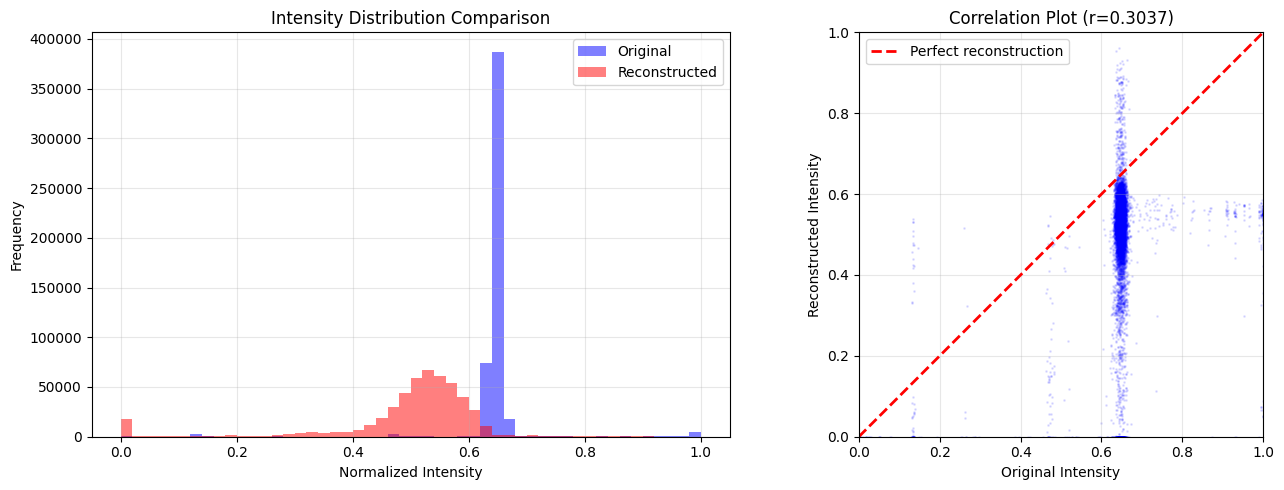

In [9]:
# ============================================================================
# STEP 5: Quantitative Evaluation
# ============================================================================

# Extract valid voxels only
orig_valid = synthetic_volume[recon_mask]
recon_valid = reconstructed_volume[recon_mask]

# Normalize to [0, 1] for fair comparison
orig_norm = (orig_valid - orig_valid.min()) / (orig_valid.max() - orig_valid.min())
recon_norm = (recon_valid - recon_valid.min()) / (recon_valid.max() - recon_valid.min())

# Calculate quality metrics
mse = np.mean((orig_norm - recon_norm) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(orig_norm - recon_norm))
correlation = np.corrcoef(orig_norm, recon_norm)[0, 1]
psnr = 20 * np.log10(1.0 / rmse) if rmse > 0 else float('inf')

print("\nReconstruction Quality Metrics:")
print(f"  MSE:         {mse:.6f}")
print(f"  RMSE:        {rmse:.6f}")
print(f"  MAE:         {mae:.6f}")
print(f"  Correlation: {correlation:.6f}")
print(f"  PSNR:        {psnr:.2f} dB")
print(f"\n  Note: Correlation near zero indicates reconstruction challenges")
print(f"        due to simplified TFM simulation. Real TFM with proper")
print(f"        beamforming would produce better results.")

# Visualize distributions and correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
axes[0].hist(orig_norm, bins=50, alpha=0.5, label='Original', color='blue')
axes[0].hist(recon_norm, bins=50, alpha=0.5, label='Reconstructed', color='red')
axes[0].set_xlabel('Normalized Intensity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Intensity Distribution Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Correlation plot
sample_idx = np.random.choice(len(orig_norm), min(10000, len(orig_norm)), replace=False)
axes[1].scatter(orig_norm[sample_idx], recon_norm[sample_idx], 
               alpha=0.1, s=1, color='blue')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect reconstruction')
axes[1].set_xlabel('Original Intensity')
axes[1].set_ylabel('Reconstructed Intensity')
axes[1].set_title(f'Correlation Plot (r={correlation:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()